In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image


In [2]:
LATENT_DIM = 100
IMG_DIM    = 28 * 28
BATCH_SIZE = 128
LR         = 2e-4
BETAS      = (0.5, 0.999)   # the famous DCGAN Adam tuning
N_EPOCHS   = 50
DEVICE     = torch.device('cuda' if torch.cuda.is_available() else 'cpu')



In [4]:
from torchvision import datasets
from torch.utils.data import DataLoader
import torchvision

# Normalize MNIST to [-1, 1] so it matches Tanh output range.
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])
train_ds = datasets.MNIST('./data', train=True, download=True, transform=transform)
train_dl = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, drop_last=True, pin_memory=True,
)

In [3]:
class Generator(nn.Module):
    def __init__(self, latent_dim=100, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, 128),
            nn.BatchNorm1d(128, momentum=0.8),
            nn.ReLU(inplace=True),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256, momentum=0.8),
            nn.ReLU(inplace=True),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512, momentum=0.8),
            nn.ReLU(inplace=True),

            nn.Linear(512, img_dim),
            nn.Tanh(),   # outputs in [-1, 1] — must match data normalization
        )

    def forward(self, z):
        return self.net(z)
    
    


class Discriminator(nn.Module):
    def __init__(self, img_dim=784):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(img_dim, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 1),
        )

    def forward(self, x):
        return self.net(x)


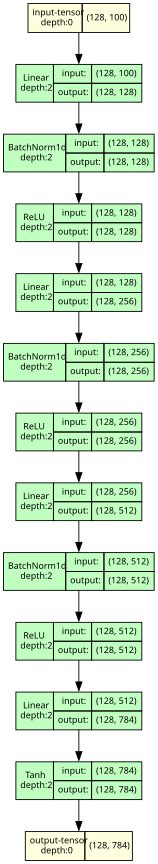

In [7]:
from torchview import draw_graph

draw_graph(
    Generator(), input_size=(BATCH_SIZE, 100), device="meta"
).visual_graph


In [7]:
# ---------- Setup ----------
G = Generator(LATENT_DIM, IMG_DIM).to(DEVICE)
D = Discriminator(IMG_DIM).to(DEVICE)

opt_G = optim.Adam(G.parameters(), lr=LR, betas=BETAS)
opt_D = optim.Adam(D.parameters(), lr=LR, betas=BETAS)

bce = nn.BCEWithLogitsLoss()
# Fixed latent vectors — sample these every epoch so you can watch the same
# noise turn into digits as training progresses.
fixed_z = torch.randn(64, LATENT_DIM, device=DEVICE)
os.makedirs('samples', exist_ok=True)

### Training

In [8]:
for epoch in range(N_EPOCHS):
    for step, (real, _) in enumerate(train_dl):
        real = real.view(real.size(0), -1).to(DEVICE)
        batch_size   = real.size(0)

        real_labels = torch.ones (batch_size, 1, device=DEVICE)
        fake_labels = torch.zeros(batch_size, 1, device=DEVICE)

        # ===== Step 1: Train Discriminator =====
        # Goal: D(real) → 1, D(G(z)) → 0
        opt_D.zero_grad()

        # Real
        d_real = D(real)
        loss_d_real = bce(d_real, real_labels)

        # Fake — generate, then DETACH so gradients don't flow into G here
        z = torch.randn(batch_size, LATENT_DIM, device=DEVICE)
        fake = G(z)
        d_fake = D(fake.detach())
        loss_d_fake = bce(d_fake, fake_labels)

        loss_d = loss_d_real + loss_d_fake
        loss_d.backward()
        opt_D.step()

        # ===== Step 2: Train Generator =====
        # Goal: make D think fakes are real (non-saturating loss)
        opt_G.zero_grad()

        # Re-run D on fake WITHOUT detach — we need gradients through G
        d_fake_for_g = D(fake)
        loss_g = bce(d_fake_for_g, real_labels)  # target=1, "fool D"

        loss_g.backward()
        opt_G.step()

        # ===== Logging =====
        if step % 200 == 0:
            with torch.no_grad():
                d_x   = torch.sigmoid(d_real).mean().item()
                d_g_z = torch.sigmoid(d_fake).mean().item()
            print(
                f"epoch {epoch:3d} step {step:4d} | "
                f"D_loss {loss_d.item():.3f}  G_loss {loss_g.item():.3f} | "
                f"D(x) {d_x:.3f}  D(G(z)) {d_g_z:.3f}"
            )

    # ===== Save sample grid per epoch =====
    G.eval()
    with torch.no_grad():
        samples = G(fixed_z).view(-1, 1, 28, 28)
        save_image(
            samples,
            f'samples/epoch_{epoch:03d}.png',
            nrow=8, normalize=True, value_range=(-1, 1),
        )
    G.train()


/Users/aslonkhamidov/Desktop/code/learning/deep_learning_mit/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:1118: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


epoch   0 step    0 | D_loss 1.372  G_loss 0.721 | D(x) 0.499  D(G(z)) 0.491
epoch   0 step  200 | D_loss 1.382  G_loss 0.748 | D(x) 0.512  D(G(z)) 0.504
epoch   0 step  400 | D_loss 1.047  G_loss 1.071 | D(x) 0.649  D(G(z)) 0.446
epoch   1 step    0 | D_loss 1.031  G_loss 1.223 | D(x) 0.589  D(G(z)) 0.356
epoch   1 step  200 | D_loss 1.070  G_loss 1.544 | D(x) 0.775  D(G(z)) 0.543
epoch   1 step  400 | D_loss 1.097  G_loss 2.259 | D(x) 0.880  D(G(z)) 0.607
epoch   2 step    0 | D_loss 0.943  G_loss 2.242 | D(x) 0.831  D(G(z)) 0.513
epoch   2 step  200 | D_loss 1.069  G_loss 1.918 | D(x) 0.809  D(G(z)) 0.552
epoch   2 step  400 | D_loss 0.943  G_loss 1.719 | D(x) 0.766  D(G(z)) 0.467
epoch   3 step    0 | D_loss 1.594  G_loss 2.458 | D(x) 0.919  D(G(z)) 0.767
epoch   3 step  200 | D_loss 1.575  G_loss 0.969 | D(x) 0.287  D(G(z)) 0.069
epoch   3 step  400 | D_loss 1.275  G_loss 2.266 | D(x) 0.899  D(G(z)) 0.673
epoch   4 step    0 | D_loss 0.876  G_loss 1.893 | D(x) 0.754  D(G(z)) 0.425